In [1]:
# Preprocessing
from setup import *

path = '/Users/jaquesgillis/.cache/kagglehub/competitions/playground-series-s6e7'
df = pd.read_csv(path + '/train.csv')
X = df.copy()
# Use the US population mean to replace missing sleep duration values
X['sleep_duration'] = X['sleep_duration'].mask(X['sleep_duration'].isnull(), other=7.0)
# Because of high variability of heart rate statistics, use the 
# sample mean for heart_rate
X['heart_rate'] = X['heart_rate'].mask(X['heart_rate'].isnull(), other=X['sleep_duration'].mean())
# https://dqydj.com gives a median bmi of 25.5 for 18-24 year olds
X['bmi'] = X['bmi'].mask(X['bmi'].isnull(), other=25.5)
# The following seem like local statistics, so I'll take the mean of the sample'
# Using median for quantitative variables and mode for categorical
X['calorie_expenditure'] = X['calorie_expenditure'].mask(X['calorie_expenditure'].isnull(), other=X['calorie_expenditure'].median())
X['step_count'] = X['step_count'].mask(X['step_count'].isnull(), other=X['step_count'].median())
X['exercise_duration'] = X['exercise_duration'].mask(X['exercise_duration'].isnull(), other=X['exercise_duration'].median())
X['water_intake'] = X['water_intake'].mask(X['water_intake'].isnull(), other=X['water_intake'].median())
X['diet_type'] = X['diet_type'].mask(X['diet_type'].isnull(), other=X['diet_type'].mode()[0])
X['stress_level'] = X['stress_level'].mask(X['stress_level'].isnull(), other=X['stress_level'].mode()[0])
X['sleep_quality'] = X['sleep_quality'].mask(X['sleep_quality'].isnull(), other=X['sleep_quality'].mode()[0])
X['physical_activity_level'] = X['physical_activity_level'].mask(X['physical_activity_level'].isnull(), X['physical_activity_level'].mode()[0])
# I'll take a pessimistic view and assume that unreported smoking/drinking means 'yes'
X['smoking_alcohol'] = X['smoking_alcohol'].mask(X['smoking_alcohol'].isnull(), other='yes')
# Create a third category, "other", for null gender values
X['gender'] = X['gender'].mask(X['gender'].isnull(), other="other")

X_with_categories = X.copy()
X = X.drop(columns=['id'])
categorical = ['diet_type', 'smoking_alcohol', 'gender']

one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

for category in categorical:
    # encode
    new_column_data = one_hot.fit_transform(X[[category]])
    # get names for the one-hot-encoded columns
    new_column_names = one_hot.get_feature_names_out([category])
    # wrap in dataframe
    new_columns = pd.DataFrame(new_column_data, columns=new_column_names)
    # attach to the main dataframe
    X = pd.concat([X.drop(columns=category, axis=1), new_columns], axis=1)
    
ordinal = ['health_condition', 'sleep_quality', 'stress_level', 'physical_activity_level']

ordinal_values = {}
ordinal_values['health_condition'] = ['unhealthy', 'at-risk', 'fit']
ordinal_values['sleep_quality'] = ['poor', 'average', 'good']
ordinal_values['stress_level'] = ['low', 'medium', 'high']
ordinal_values['physical_activity_level'] = ['sedentary', 'moderate', 'active']

for category in ordinal:
    encoder = OrdinalEncoder(categories=[ordinal_values[category]])
    X[category + '_encoded'] = encoder.fit_transform(X[[category]])
    X.drop(columns=[category], inplace=True)

y = X.pop('health_condition_encoded')

/opt/miniconda3/envs/kaggle-astro/lib/python3.10/site-packages/lofo/lofo_importance.py:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Feature engineering

Below I create some new features based on initial hypotheses and patterns observed in EDA. First, though, I'll split the training and test set and normalize the data to make it easier to compare and combine features.

In [2]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

In [3]:
train_X.head()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,diet_type_non-veg,diet_type_veg,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_other,sleep_quality_encoded,stress_level_encoded,physical_activity_level_encoded
652972,7.76,80.9,22.51,1828.0,4368.0,35.3,2.38,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,1.0
226392,4.58,86.8,23.45,2241.0,6183.0,52.0,1.19,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0
651569,9.32,75.6,23.19,2539.0,7648.0,25.8,2.05,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
47990,6.62,68.9,23.68,2075.0,12409.0,56.6,2.84,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
582945,6.61,85.7,23.06,2123.0,11859.0,62.9,2.70,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,2.0,2.0


In [4]:
nonnormal = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 
             'step_count', 'exercise_duration', 'water_intake']

for cat in nonnormal:
    train_X[cat + '_norm'] = train_X[cat] / train_X[cat].max()
    val_X[cat + '_norm'] = val_X[cat] / val_X[cat].max()

In [5]:
# Subtract physical activity (maybe independent) from sleep_duration, sleep_quality, 
# and stress_level. First multiply physical activity by some contribution factor

contribution_factor = 0.3
train_X['sleep_duration_no_activity'] = train_X['sleep_duration_norm'] - contribution_factor * train_X['physical_activity_level_encoded']
train_X['sleep_quality_encoded_no_activity'] = train_X['sleep_quality_encoded'] - contribution_factor * train_X['physical_activity_level_encoded']
train_X['stress_level_no_activity'] = train_X['stress_level_encoded'] - contribution_factor * train_X['physical_activity_level_encoded']


val_X['sleep_duration_no_activity'] = val_X['sleep_duration_norm'] - contribution_factor * val_X['physical_activity_level_encoded']
val_X['sleep_quality_encoded_no_activity'] = val_X['sleep_quality_encoded'] - contribution_factor * val_X['physical_activity_level_encoded']
val_X['stress_level_no_activity'] = val_X['stress_level_encoded'] - contribution_factor * val_X['physical_activity_level_encoded']

In [11]:
train_X['sleep_duration_no_activity'].describe()

count    517566.000000
mean          0.402276
std           0.263260
min          -0.300000
25%           0.181000
50%           0.400000
75%           0.630000
max           1.000000
Name: sleep_duration_no_activity, dtype: float64

In [12]:
train_X['sleep_quality_encoded_no_activity'].describe()

count    517566.000000
mean          0.693247
std           0.813339
min          -0.600000
25%           0.000000
50%           0.700000
75%           1.400000
max           2.000000
Name: sleep_quality_encoded_no_activity, dtype: float64

In [13]:
train_X['stress_level_no_activity'].describe()

count    517566.000000
mean          0.717358
std           0.749982
min          -0.600000
25%           0.400000
50%           0.700000
75%           1.400000
max           2.000000
Name: stress_level_no_activity, dtype: float64

In [6]:
# The 'fit' category seemed to have higher step counts and exercise 
# duration than the other groups

train_X['step_count_high'] = (train_X['step_count'] > 9000)
train_X['exercise_duration_high'] = (train_X['exercise_duration'] > 45)

val_X['step_count_high'] = (val_X['step_count'] > 9000)
val_X['exercise_duration_high'] = (val_X['exercise_duration'] > 45)

In [7]:
# A number of features seem to change when the heart rate is over 68 
# and again when it is over 78.

train_X['bmi_high_hr'] = train_X['bmi'].where(train_X['heart_rate']<=68, other=2*train_X['bmi'])
train_X['smoking_high_hr'] = train_X['smoking_alcohol_yes'].where(train_X['heart_rate']<=68, other=2*train_X['smoking_alcohol_yes'])
train_X['sleep_qual_high_hr'] = train_X['sleep_quality_encoded'].where(train_X['heart_rate']>=68, other=2*train_X['sleep_quality_encoded'])


val_X['bmi_high_hr'] = val_X['bmi'].where(val_X['heart_rate']<=68, other=2*val_X['bmi'])
val_X['smoking_high_hr'] = val_X['smoking_alcohol_yes'].where(val_X['heart_rate']<=68, other=2*val_X['smoking_alcohol_yes'])
val_X['sleep_qual_high_hr'] = val_X['sleep_quality_encoded'].where(val_X['heart_rate']>=68, other=2*val_X['sleep_quality_encoded'])

In [8]:
# sleep quality, stress level, and smoking/alcohol for low and moderate 
# activity levels, replaced by high activity level where present
train_X['sleep_quality_active'] = train_X['sleep_quality_encoded'].where(train_X['physical_activity_level_encoded'] <= 1, other=train_X['physical_activity_level_encoded'])
train_X['stress_level_active'] = train_X['stress_level_encoded'].where(train_X['physical_activity_level_encoded'] <= 1, other=train_X['physical_activity_level_encoded'])
train_X['smoking_active'] = train_X['smoking_alcohol_no'].where(train_X['physical_activity_level_encoded'] <= 1, other=train_X['physical_activity_level_encoded'])


val_X['sleep_quality_active'] = val_X['sleep_quality_encoded'].where(val_X['physical_activity_level_encoded'] <= 1, other=val_X['physical_activity_level_encoded'])
val_X['stress_level_active'] = val_X['stress_level_encoded'].where(val_X['physical_activity_level_encoded'] <= 1, other=val_X['physical_activity_level_encoded'])
val_X['smoking_active'] = val_X['smoking_alcohol_no'].where(val_X['physical_activity_level_encoded'] <= 1, other=val_X['physical_activity_level_encoded'])

train_X.head()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,diet_type_non-veg,diet_type_veg,...,sleep_quality_encoded_no_activity,stress_level_no_activity,step_count_high,exercise_duration_high,bmi_high_hr,smoking_high_hr,sleep_qual_high_hr,sleep_quality_active,stress_level_active,smoking_active
652972,7.76,80.9,22.51,1828.0,4368.0,35.3,2.38,0.0,0.0,1.0,...,1.7,-0.3,False,False,45.02,2.0,2.0,2.0,0.0,0.0
226392,4.58,86.8,23.45,2241.0,6183.0,52.0,1.19,1.0,0.0,0.0,...,-0.6,-0.6,False,True,46.90,2.0,0.0,2.0,2.0,2.0
651569,9.32,75.6,23.19,2539.0,7648.0,25.8,2.05,1.0,0.0,0.0,...,2.0,0.0,False,False,46.38,0.0,2.0,2.0,0.0,0.0
47990,6.62,68.9,23.68,2075.0,12409.0,56.6,2.84,1.0,0.0,0.0,...,-0.6,-0.6,True,True,47.36,0.0,0.0,2.0,2.0,2.0
582945,6.61,85.7,23.06,2123.0,11859.0,62.9,2.70,0.0,0.0,1.0,...,1.4,1.4,True,True,46.12,2.0,2.0,2.0,2.0,2.0


In [107]:
X.columns

Index(['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'diet_type_balanced',
       'diet_type_non-veg', 'diet_type_veg', 'smoking_alcohol_no',
       'smoking_alcohol_occasional', 'smoking_alcohol_yes', 'gender_female',
       'gender_male', 'gender_other', 'sleep_quality_encoded',
       'stress_level_encoded', 'physical_activity_level_encoded'],
      dtype='object')

In [108]:
train_X.columns

Index(['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'diet_type_balanced',
       'diet_type_non-veg', 'diet_type_veg', 'smoking_alcohol_no',
       'smoking_alcohol_occasional', 'smoking_alcohol_yes', 'gender_female',
       'gender_male', 'gender_other', 'sleep_quality_encoded',
       'stress_level_encoded', 'physical_activity_level_encoded',
       'sleep_duration_norm', 'heart_rate_norm', 'bmi_norm',
       'calorie_expenditure_norm', 'step_count_norm', 'exercise_duration_norm',
       'water_intake_norm', 'sleep_duration_no_activity',
       'sleep_quality_encoded_no_activity', 'stress_level_no_activity',
       'step_count_high', 'exercise_duration_high', 'bmi_high_hr',
       'smoking_high_hr', 'sleep_qual_high_hr', 'sleep_quality_active',
       'stress_level_active', 'smoking_active'],
      dtype='object')

In [9]:
#Train a new model

features = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'smoking_alcohol_no',
       'smoking_alcohol_occasional', 'smoking_alcohol_yes', 'gender_female',
       'gender_male', 'gender_other', 'sleep_quality_encoded',
       'stress_level_encoded', 'physical_activity_level_encoded',
       'sleep_duration_norm', 'heart_rate_norm', 'bmi_norm',
       'calorie_expenditure_norm', 'step_count_norm', 'exercise_duration_norm',
       'water_intake_norm', 'sleep_duration_no_activity',
       'sleep_quality_encoded_no_activity', 'stress_level_no_activity',
       'step_count_high', 'exercise_duration_high', 'bmi_high_hr',
       'smoking_high_hr', 'sleep_qual_high_hr', 'sleep_quality_active',
       'stress_level_active', 'smoking_active']

rf_model = RandomForestClassifier(n_estimators=100, max_depth=9)
rf_model.fit(train_X, train_y)
val_predictions = rf_model.predict(val_X)
print(f"Balanced accuracy score with engineered features: {balanced_accuracy_score(val_y, val_predictions)}")

Balanced accuracy score with engineered features: 0.84640618484789


In [111]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
scores = cross_val_score(rf_model, train_X, train_y, cv=skf, scoring='balanced_accuracy')

In [112]:
print(f"cross val scores: {scores}")

cross val scores: [0.84418761 0.8454854  0.85047679 0.85090743 0.84054478]


In [ ]:
import math
from sklearn.model_selection import GridSearchCV
# Let's fine tune random forest

rfc = RandomForestClassifier()

param_grid = {
    'n_estimators': [100, 1000],
    'max_features': [math.sqrt(len(train_X.columns)), len(train_X.columns)],
    'max_depth': [5, 10, 20],
    'min_samples_leaf': [1, 10]
    
}
grid_search = GridSearchCV(rfc, param_grid, cv=5)
grid_search.fit(train_X, train_y)

<Axes: xlabel='param_max_features', ylabel='param_n_estimators'>

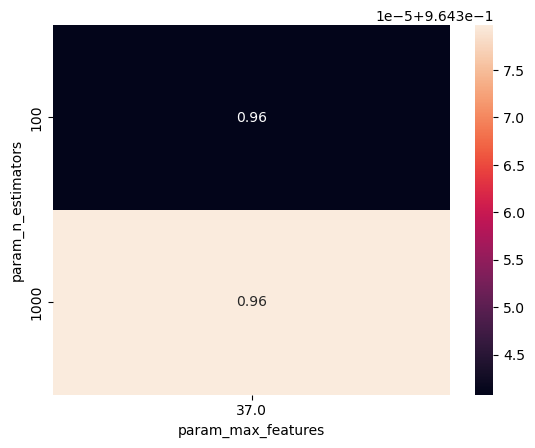

In [12]:
import seaborn as sns

grid_results_df = pd.DataFrame(grid_search.cv_results_)

viz_data = grid_results_df.pivot_table(index='param_n_estimators', columns='param_max_features', values='mean_test_score')
sns.heatmap(viz_data, annot=True)

<Axes: xlabel='param_max_depth', ylabel='param_min_samples_leaf'>

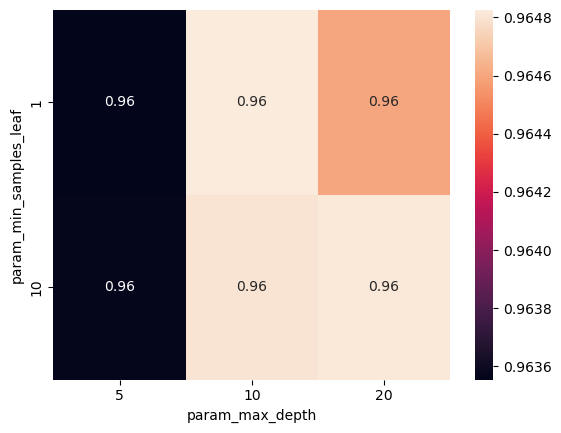

In [13]:
viz_data = grid_results_df.pivot_table(index='param_min_samples_leaf', columns='param_max_depth', values='mean_test_score')
sns.heatmap(viz_data, annot=True)

<Axes: xlabel='param_max_depth', ylabel='param_n_estimators'>

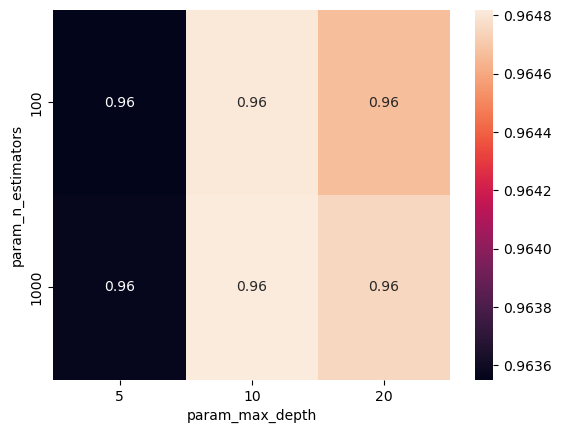

In [14]:
viz_data = grid_results_df.pivot_table(index='param_n_estimators', columns='param_max_depth', values='mean_test_score')
sns.heatmap(viz_data, annot=True)

<Axes: xlabel='param_min_samples_leaf', ylabel='param_n_estimators'>

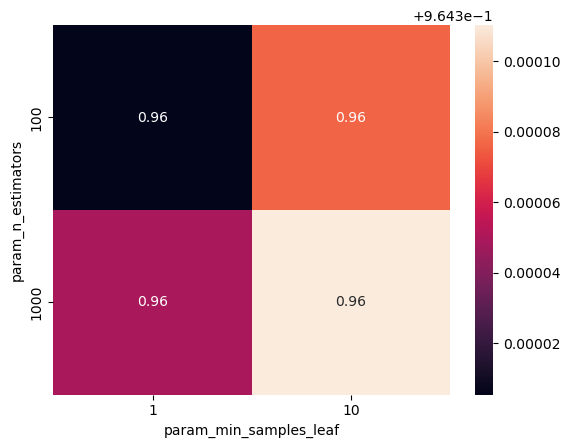

In [17]:
viz_data = grid_results_df.pivot_table(index='param_n_estimators', columns='param_min_samples_leaf', values='mean_test_score')
sns.heatmap(viz_data, annot=True)

In [ ]:
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

base_models = [
    ('rfc', RandomForestClassifier(max_depth=10, n_estimators=1000, min_samples_leaf=10)),
    ('xgb', XGBClassifier(max_depth=11, colsample_bytree=0.8, learning_rate=0.5)),
    ('lgb', LGBMClassifier(n_estimators=1000, learning_rate=0.1)),
    ('cbc', CatBoostClassifier(auto_class_weights='Balanced'))
]

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegressionCV(max_iter=1000),
    cv=skf
)

stack.fit(train_X, train_y)

scores = cross_val_score(stack, train_X, train_y, cv=skf, scoring='balanced_accuracy')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4143
[LightGBM] [Info] Number of data points in the train set: 517566, number of used features: 37
[LightGBM] [Info] Start training from score -2.478770
[LightGBM] [Info] Start training from score -0.152698
[LightGBM] [Info] Start training from score -2.851379
Learning rate set to 0.108827
0:	learn: 0.9458926	total: 110ms	remaining: 1m 49s
1:	learn: 0.8378143	total: 152ms	remaining: 1m 15s
2:	learn: 0.7517874	total: 191ms	remaining: 1m 3s
3:	learn: 0.6817682	total: 239ms	remaining: 59.6s
4:	learn: 0.6240186	total: 279ms	remaining: 55.6s
5:	learn: 0.5747921	total: 320ms	remaining: 53s
6:	learn: 0.5337374	total: 361ms	remaining: 51.2s
7:	learn: 0.4993231	total: 405ms	remaining: 50.2s
8:	learn: 0.4697408	total: 447ms	remaining: 49.2s
9:	l

151:	learn: 0.2253039	total: 6.29s	remaining: 35.1s
152:	learn: 0.2252269	total: 6.34s	remaining: 35.1s
153:	learn: 0.2251719	total: 6.37s	remaining: 35s
154:	learn: 0.2251169	total: 6.41s	remaining: 34.9s
155:	learn: 0.2250435	total: 6.46s	remaining: 34.9s
156:	learn: 0.2248763	total: 6.5s	remaining: 34.9s
157:	learn: 0.2248070	total: 6.54s	remaining: 34.8s
158:	learn: 0.2247603	total: 6.58s	remaining: 34.8s
159:	learn: 0.2246507	total: 6.63s	remaining: 34.8s
160:	learn: 0.2245818	total: 6.68s	remaining: 34.8s
161:	learn: 0.2245285	total: 6.72s	remaining: 34.8s
162:	learn: 0.2244707	total: 6.76s	remaining: 34.7s
163:	learn: 0.2244086	total: 6.79s	remaining: 34.6s
164:	learn: 0.2243507	total: 6.83s	remaining: 34.6s
165:	learn: 0.2242970	total: 6.87s	remaining: 34.5s
166:	learn: 0.2242516	total: 6.9s	remaining: 34.4s
167:	learn: 0.2241866	total: 6.94s	remaining: 34.4s
168:	learn: 0.2241457	total: 6.98s	remaining: 34.3s
169:	learn: 0.2240578	total: 7.02s	remaining: 34.3s
170:	learn: 0.22

315:	learn: 0.2154839	total: 12.8s	remaining: 27.7s
316:	learn: 0.2154148	total: 12.8s	remaining: 27.6s
317:	learn: 0.2153632	total: 12.9s	remaining: 27.6s
318:	learn: 0.2153353	total: 12.9s	remaining: 27.5s
319:	learn: 0.2152958	total: 12.9s	remaining: 27.5s
320:	learn: 0.2152620	total: 13s	remaining: 27.5s
321:	learn: 0.2152414	total: 13s	remaining: 27.4s
322:	learn: 0.2151868	total: 13.1s	remaining: 27.4s
323:	learn: 0.2151432	total: 13.1s	remaining: 27.3s
324:	learn: 0.2150843	total: 13.1s	remaining: 27.3s
325:	learn: 0.2150394	total: 13.2s	remaining: 27.2s
326:	learn: 0.2149985	total: 13.2s	remaining: 27.2s
327:	learn: 0.2149275	total: 13.3s	remaining: 27.2s
328:	learn: 0.2148567	total: 13.3s	remaining: 27.1s
329:	learn: 0.2148089	total: 13.3s	remaining: 27.1s
330:	learn: 0.2147700	total: 13.4s	remaining: 27s
331:	learn: 0.2147248	total: 13.4s	remaining: 27s
332:	learn: 0.2146503	total: 13.5s	remaining: 27s
333:	learn: 0.2145934	total: 13.5s	remaining: 26.9s
334:	learn: 0.2145388	

475:	learn: 0.2080068	total: 19.3s	remaining: 21.2s
476:	learn: 0.2079819	total: 19.3s	remaining: 21.2s
477:	learn: 0.2079465	total: 19.4s	remaining: 21.2s
478:	learn: 0.2078769	total: 19.4s	remaining: 21.1s
479:	learn: 0.2078261	total: 19.5s	remaining: 21.1s
480:	learn: 0.2077690	total: 19.5s	remaining: 21s
481:	learn: 0.2077387	total: 19.5s	remaining: 21s
482:	learn: 0.2077218	total: 19.6s	remaining: 20.9s
483:	learn: 0.2076755	total: 19.6s	remaining: 20.9s
484:	learn: 0.2076210	total: 19.7s	remaining: 20.9s
485:	learn: 0.2075857	total: 19.7s	remaining: 20.9s
486:	learn: 0.2075338	total: 19.8s	remaining: 20.8s
487:	learn: 0.2074900	total: 19.8s	remaining: 20.8s
488:	learn: 0.2074596	total: 19.8s	remaining: 20.7s
489:	learn: 0.2074201	total: 19.9s	remaining: 20.7s
490:	learn: 0.2073931	total: 19.9s	remaining: 20.7s
491:	learn: 0.2073220	total: 20s	remaining: 20.6s
492:	learn: 0.2072840	total: 20s	remaining: 20.6s
493:	learn: 0.2072376	total: 20.1s	remaining: 20.5s
494:	learn: 0.207195

636:	learn: 0.2014288	total: 25.9s	remaining: 14.7s
637:	learn: 0.2013798	total: 25.9s	remaining: 14.7s
638:	learn: 0.2013299	total: 25.9s	remaining: 14.7s
639:	learn: 0.2012719	total: 26s	remaining: 14.6s
640:	learn: 0.2012438	total: 26s	remaining: 14.6s
641:	learn: 0.2012193	total: 26.1s	remaining: 14.5s
642:	learn: 0.2011752	total: 26.1s	remaining: 14.5s
643:	learn: 0.2011374	total: 26.1s	remaining: 14.5s
644:	learn: 0.2010976	total: 26.2s	remaining: 14.4s
645:	learn: 0.2010486	total: 26.2s	remaining: 14.4s
646:	learn: 0.2010177	total: 26.3s	remaining: 14.3s
647:	learn: 0.2009771	total: 26.3s	remaining: 14.3s
648:	learn: 0.2009468	total: 26.4s	remaining: 14.3s
649:	learn: 0.2008843	total: 26.4s	remaining: 14.2s
650:	learn: 0.2008580	total: 26.4s	remaining: 14.2s
651:	learn: 0.2008386	total: 26.5s	remaining: 14.1s
652:	learn: 0.2007912	total: 26.5s	remaining: 14.1s
653:	learn: 0.2007495	total: 26.6s	remaining: 14s
654:	learn: 0.2007047	total: 26.6s	remaining: 14s
655:	learn: 0.200671

798:	learn: 0.1953924	total: 32.6s	remaining: 8.2s
799:	learn: 0.1953592	total: 32.6s	remaining: 8.16s
800:	learn: 0.1953252	total: 32.7s	remaining: 8.12s
801:	learn: 0.1952850	total: 32.7s	remaining: 8.08s
802:	learn: 0.1952532	total: 32.8s	remaining: 8.04s
803:	learn: 0.1952104	total: 32.8s	remaining: 8s
804:	learn: 0.1951818	total: 32.8s	remaining: 7.96s
805:	learn: 0.1951317	total: 32.9s	remaining: 7.91s
806:	learn: 0.1950985	total: 32.9s	remaining: 7.87s
807:	learn: 0.1950792	total: 33s	remaining: 7.83s
808:	learn: 0.1950466	total: 33s	remaining: 7.79s
809:	learn: 0.1950279	total: 33s	remaining: 7.75s
810:	learn: 0.1950059	total: 33.1s	remaining: 7.71s
811:	learn: 0.1949919	total: 33.1s	remaining: 7.67s
812:	learn: 0.1949512	total: 33.2s	remaining: 7.63s
813:	learn: 0.1949217	total: 33.2s	remaining: 7.59s
814:	learn: 0.1948712	total: 33.2s	remaining: 7.54s
815:	learn: 0.1948341	total: 33.3s	remaining: 7.5s
816:	learn: 0.1948155	total: 33.3s	remaining: 7.46s
817:	learn: 0.1947929	t

961:	learn: 0.1901121	total: 39.4s	remaining: 1.56s
962:	learn: 0.1900944	total: 39.5s	remaining: 1.51s
963:	learn: 0.1900654	total: 39.5s	remaining: 1.47s
964:	learn: 0.1900473	total: 39.5s	remaining: 1.43s
965:	learn: 0.1900115	total: 39.6s	remaining: 1.39s
966:	learn: 0.1899670	total: 39.6s	remaining: 1.35s
967:	learn: 0.1899350	total: 39.7s	remaining: 1.31s
968:	learn: 0.1899001	total: 39.7s	remaining: 1.27s
969:	learn: 0.1898752	total: 39.7s	remaining: 1.23s
970:	learn: 0.1898605	total: 39.8s	remaining: 1.19s
971:	learn: 0.1898193	total: 39.8s	remaining: 1.15s
972:	learn: 0.1897782	total: 39.9s	remaining: 1.11s
973:	learn: 0.1897380	total: 39.9s	remaining: 1.06s
974:	learn: 0.1897081	total: 40s	remaining: 1.02s
975:	learn: 0.1896609	total: 40s	remaining: 984ms
976:	learn: 0.1896324	total: 40s	remaining: 943ms
977:	learn: 0.1895830	total: 40.1s	remaining: 902ms
978:	learn: 0.1895620	total: 40.1s	remaining: 861ms
979:	learn: 0.1895299	total: 40.2s	remaining: 820ms
980:	learn: 0.1895

In [19]:
print(f"cross val scores: {scores}")

cross val scores: [0.8611858  0.86249266 0.84995195 0.86661554 0.85980312]
